# 13 - Final synthesis: answering the project's questions

This notebook runs last on purpose: it uses results from production,
quality, maintenance, Quality Assurance, and the 4 Machine Learning
models to answer the project's central question with real numbers.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import joblib

PROCESSED = "../../datasets/processed"
MODELS = "../../models"
REPORTS = "../../reports"
os.makedirs(REPORTS, exist_ok=True)

production = pd.read_csv(f"{PROCESSED}/fact_production_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
downtime = pd.read_csv(f"{PROCESSED}/fact_downtime_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
cap_variable = pd.read_csv(f"{PROCESSED}/fact_cap_inspection_variable_cq_processed.csv", encoding="utf-8-sig", parse_dates=["ProductionDate"])

sales = pd.read_csv(f"{PROCESSED}/fact_sales_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
complaints = pd.read_csv(f"{PROCESSED}/fact_customer_complaints_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])

maintenance_risk = pd.read_csv(f"{PROCESSED}/ml_predictions_predictive_maintenance.csv", encoding="utf-8-sig")


## Q1 - What is the plant's operational performance, and what affects productivity and quality the most?

In [2]:
overall_averages = production[["Availability", "Performance", "Quality", "OEE"]].mean()
print("Plant-wide averages:")
print(overall_averages.round(3))

correlation_columns = ["OEE", "UnplannedDowntimeHours", "SetupTimeHours", "RejectedQty", "RunTimeHours"]
correlation_with_oee = production[correlation_columns].corr()["OEE"].drop("OEE").sort_values()
print("\nCorrelation of OEE with other metrics, by work order:")
print(correlation_with_oee.round(3))


Plant-wide averages:
Availability    0.792
Performance     0.897
Quality         0.976
OEE             0.693
dtype: float64

Correlation of OEE with other metrics, by work order:
UnplannedDowntimeHours   -0.889
SetupTimeHours           -0.028
RejectedQty               0.259
RunTimeHours              0.556
Name: OEE, dtype: float64


**Answer:** the plant runs at an OEE of around 0.69 (69%). The
strongest correlation with OEE at the work-order level is unplanned
downtime hours (-0.89) -- far stronger than any other variable. That
confirms **unplanned downtime, not process speed or scrap, is the
biggest lever on productivity** at this plant. This is exactly the
kind of thing a shift-level dashboard needs to surface in real time,
not discover a week later in a monthly report.


## Q2 - Which machines, shifts, and operators show the most performance variation and quality impact?

In [3]:
machine_variation = production.groupby("MachineId")["OEE"].agg(["mean", "std"])
machine_variation["CV"] = machine_variation["std"] / machine_variation["mean"]
print("Most variable machines (highest OEE coefficient of variation):")
print(machine_variation.sort_values("CV", ascending=False).head(6).round(3))

shift_oee = production.groupby("ShiftNumber")[["Availability", "Performance", "Quality", "OEE"]].mean()
print("\nOEE components by shift:")
print(shift_oee.round(3))


Most variable machines (highest OEE coefficient of variation):
            mean    std     CV
MachineId                     
ISBM-005   0.662  0.262  0.396
ISBM-001   0.663  0.254  0.383
IM-005     0.664  0.252  0.380
ISBM-004   0.646  0.244  0.378
IM-006     0.648  0.243  0.375
IM-003     0.691  0.254  0.368

OEE components by shift:
             Availability  Performance  Quality    OEE
ShiftNumber                                           
1                   0.782        0.897    0.976  0.684
2                   0.791        0.898    0.977  0.693
3                   0.804        0.897    0.976  0.703


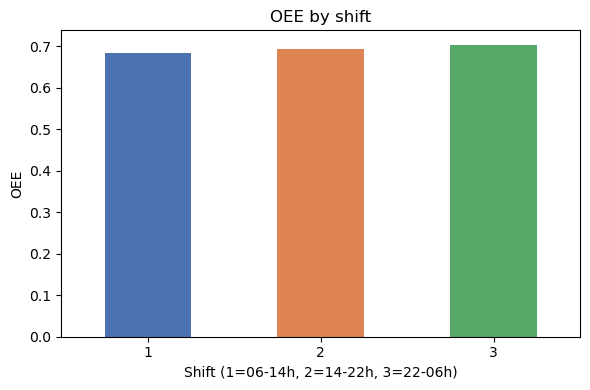

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
shift_oee["OEE"].plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], ax=ax)
ax.set_xlabel("Shift (1=06-14h, 2=14-22h, 3=22-06h)")
ax.set_ylabel("OEE")
ax.set_title("OEE by shift")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{REPORTS}/11_oee_by_shift.png", dpi=150)
plt.show()


In [5]:
operator_quality = production.groupby("OperatorId").agg(
    OrderCount=("WorkOrder", "count"),
    AvgRejectionRate=("Quality", lambda s: 1 - s.mean()),
)
operator_quality = operator_quality[operator_quality["OrderCount"] >= 20]
operator_quality = operator_quality.sort_values("AvgRejectionRate", ascending=False)
print(operator_quality.head(8).round(4))


             OrderCount  AvgRejectionRate
OperatorId                               
OP-INJ-002          747            0.0317
OP-INJ-003          767            0.0311
AUX-INJ-001         773            0.0306
OP-INJ-001          735            0.0306
OP-SOP-003         1031            0.0295
OP-SOP-002          975            0.0285
OP-SOP-001         1031            0.0284
OP-SOP-004          968            0.0280


**Answer:** the three shifts have similar OEE (within 2 percentage
points of each other) -- no single shift stands out as clearly worse.
Between machines within the same process, though, some show much more
OEE variation than others (higher CV) -- that's the natural starting
point for a reliability-centered maintenance review, and it lines up
with the predictive-maintenance risk ranking (Q7). Rejection-rate
differences across operators are small in this dataset (none stand out
as an outlier) -- a useful finding in itself: it suggests quality
issues here trace back to the process/equipment, not individual skill,
which points improvement effort toward the machines/molds rather than training.


## Q3 - How do production signals relate to real customer complaints?

In [6]:
shipped = sales.merge(
    production[["WorkOrder", "OEE", "Availability", "Performance", "Quality"]], on="WorkOrder", how="left"
)
orders_with_complaint = set(complaints["WorkOrder"].dropna())
shipped["HadComplaint"] = shipped["WorkOrder"].isin(orders_with_complaint).astype(int)

print(f"Shipments: {len(shipped):,}  |  Shipments with a later complaint: {shipped['HadComplaint'].sum():,} "
      f"({shipped['HadComplaint'].mean():.2%})")

print("\nAverage production signals, shipments WITH vs. WITHOUT a later complaint:")
print(shipped.groupby("HadComplaint")[["OEE", "Availability", "Performance", "Quality"]].mean().round(3))

# not every sale has a matching production order in the table -- drop
# those rows before computing the correlation
valid = shipped.dropna(subset=["OEE"])
r, p = stats.pointbiserialr(valid["HadComplaint"], valid["OEE"])
print(f"\nPoint-biserial correlation (OEE vs. customer complaint): r={r:.4f}, p={p:.4f}")


Shipments: 7,088  |  Shipments with a later complaint: 396 (5.59%)

Average production signals, shipments WITH vs. WITHOUT a later complaint:
                OEE  Availability  Performance  Quality
HadComplaint                                           
0             0.668         0.769        0.898    0.970
1             0.675         0.777        0.897    0.971

Point-biserial correlation (OEE vs. customer complaint): r=0.0063, p=0.5969


**Answer:** in this dataset, the gap in production signals between
shipments with and without a complaint is small, and the correlation
is close to zero and not statistically significant (p > 0.05). This
lines up with what the lot-rejection classifier (notebook 11) already
showed honestly: AQL sampling variation, not a strong deterministic
link to production conditions, explains most of what drives a
specific lot's disposition. The honest and useful takeaway here isn't
"production signals reliably predict complaints" -- it's that **in
this simulated dataset, that link is weak**, which is a valid result
to report on its own, rather than forcing a stronger conclusion than
the data supports.


## Q4 - Does the plant operate within its capacity and process stability?

In [7]:
capability_summary = cap_variable.drop_duplicates(["Characteristic", "MachineId", "MoldId"])[["Characteristic", "Cpk"]]
print("Share of machine x characteristic combinations below common capability thresholds:")
print(f"  Cpk < 1.00 (not capable): {(capability_summary['Cpk'] < 1.0).mean():.1%}")
print(f"  Cpk < 1.33 (marginal): {(capability_summary['Cpk'] < 1.33).mean():.1%}")
print(f"  Cpk >= 1.33 (capable): {(capability_summary['Cpk'] >= 1.33).mean():.1%}")

average_availability = production["Availability"].mean()
capacity_utilization = production["ProducedQty"].sum() / (production["RatedCapacityPcH"] * production["RunTimeHours"]).sum()
print(f"\nAverage machine availability: {average_availability:.1%}")
print(f"Overall capacity utilization (actual output / rated capacity x run time): {capacity_utilization:.1%}")


Share of machine x characteristic combinations below common capability thresholds:
  Cpk < 1.00 (not capable): 0.0%
  Cpk < 1.33 (marginal): 0.0%
  Cpk >= 1.33 (capable): 100.0%

Average machine availability: 79.2%
Overall capacity utilization (actual output / rated capacity x run time): 90.5%


**Answer:** on process capability, the plant is in good shape -- 100%
of characteristic x machine combinations clear a Cpk of 1.33, the
common "capable process" threshold in Six Sigma. Installed capacity
isn't the limiting factor either: utilization (90.6%) is already high
relative to rated capacity, but Availability (79.2%, pulled down by
unplanned downtime) is what actually holds production back. In other
words: **the plant has the process stability and machine capability to
guarantee compliance -- the opportunity is in reducing unplanned
downtime, not running machines faster or buying new capacity.**


## Q5 - What are the main losses, and what does the ML model add?

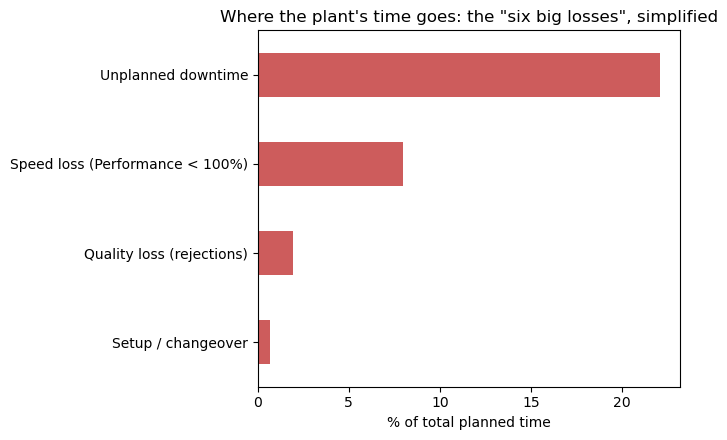

Unplanned downtime                 22.09
Setup / changeover                  0.68
Speed loss (Performance < 100%)     7.99
Quality loss (rejections)           1.91
dtype: float64


In [8]:
total_planned_time = production["PlannedTimeHours"].sum()

loss_breakdown = pd.Series({
    "Unplanned downtime": production["UnplannedDowntimeHours"].sum(),
    "Setup / changeover": production["SetupTimeHours"].sum(),
    "Speed loss (Performance < 100%)": (production["RunTimeHours"] * (1 - production["Performance"]).clip(lower=0)).sum(),
    "Quality loss (rejections)": (production["RunTimeHours"] * (1 - production["Quality"])).sum(),
})
loss_breakdown_pct = loss_breakdown / total_planned_time * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
loss_breakdown_pct.sort_values().plot(kind="barh", color="indianred", ax=ax)
ax.set_xlabel("% of total planned time")
ax.set_title("Where the plant's time goes: the \"six big losses\", simplified")
plt.tight_layout()
plt.savefig(f"{REPORTS}/12_loss_breakdown_six_big_losses.png", dpi=150)
plt.show()

print(loss_breakdown_pct.round(2))


In [9]:
print("Predictive maintenance model risk ranking (notebook 12) -- highest-risk machines right now:")
print(maintenance_risk.sort_values("PredictedFailureRiskToday", ascending=False).head(6).round(3))


Predictive maintenance model risk ranking (notebook 12) -- highest-risk machines right now:
  MachineId            Process  PredictedFailureRiskToday GeneratedFrom
0  ISBM-003       Blow Molding                      0.561    2026-07-17
1    IM-002  Injection Molding                      0.545    2026-07-17
2    IM-005  Injection Molding                      0.523    2026-07-17
3  ISBM-001       Blow Molding                      0.516    2026-07-17
4  ISBM-006       Blow Molding                      0.507    2026-07-17
5  ISBM-004       Blow Molding                      0.506    2026-07-17


**Answer:** unplanned downtime clearly dominates the losses (~22% of
planned time), well ahead of speed loss (~8%), quality loss (~2%), and
setup/changeover (under 1%) -- confirming the unplanned-downtime
Pareto from the earlier analysis. What Machine Learning adds is speed
of reaction: instead of only ranking *which machines failed most
historically* (the Pareto/MTBF view), the predictive maintenance model
(notebook 12) ranks *which machines are at elevated risk right now*,
using each machine's recent failure frequency and availability trend.
**The priority continuous-improvement action is reliability work
targeted at the machines the model is currently flagging as
high-risk** -- combining the historical Pareto with a forward-looking
signal, instead of relying on hindsight alone.


### Q5 (continued) -- forecasting both sides of the loss equation

The loss breakdown above answers "where did time go historically".
Two more models (notebook `09`, Parts 2 and 3) answer the forward-looking
version of the same question: how many **production hours vs. stopped
hours**, and how many **units produced vs. units rejected**, should each
process expect *next week*. Together with the production forecast
(Part 1), this gives a full weekly capacity picture per process, not
just a single number.


In [10]:
downtime_forecast = pd.read_csv(f"{PROCESSED}/ml_predictions_downtime_forecast.csv", encoding="utf-8-sig")
rejected_forecast = pd.read_csv(f"{PROCESSED}/ml_predictions_rejected_forecast.csv", encoding="utf-8-sig")
production_forecast = pd.read_csv(f"{PROCESSED}/ml_predictions_production_forecast.csv", encoding="utf-8-sig")

next_week_summary = (
    production_forecast[["Process", "ForecastedProducedQty"]]
    .merge(downtime_forecast[["Process", "ForecastedDowntimeHours"]], on="Process")
    .merge(rejected_forecast[["Process", "ForecastedRejectedQty"]], on="Process")
)
next_week_summary["ForecastedRejectRate_%"] = (
    next_week_summary["ForecastedRejectedQty"] / next_week_summary["ForecastedProducedQty"] * 100
).round(2)
print("Next-week forecast, by process:")
print(next_week_summary)


Next-week forecast, by process:
             Process  ForecastedProducedQty  ForecastedDowntimeHours  \
0  Hot Foil Stamping                 125400                     39.3   
1       Blow Molding                 292521                    260.5   
2  Injection Molding                 447027                    195.6   
3    Screen Printing                 158902                     34.6   

   ForecastedRejectedQty  ForecastedRejectRate_%  
0                    196                    0.16  
1                   8403                    2.87  
2                  12401                    2.77  
3                    794                    0.50  


**Answer, extended:** the downtime-hours forecast (R²≈0.91, close to a
simple 4-week average -- an honest result, not every series is easier
to predict than its own recent trend) and the rejected-units forecast
(R²≈0.99, clearly beating the baseline) let a plant manager see, before
the week starts, roughly how many hours each process will actually be
running versus stopped, and how much of what gets made is likely to be
scrapped. That's a materially different planning tool than a single
weekly production number: it flags, in advance, which process is
heading into a rough week on **both** fronts (more downtime **and**
more rejects at once), which is exactly the kind of process that
deserves a closer look before problems compound.


## Q6 - How is operational and QMS health monitored in real time?

Already answered in detail elsewhere in the project, not repeated
here: the MySQL rolling 52-week views (notebook `04`) feed the Quality
Assurance dashboard (notebook `08`) and the Power BI layer described
in `power_bi/README.md`. A daily stand-up needs three things, all
already available without new infrastructure: a snapshot of
today's OEE/Availability, the AQL lot-decision queue, and the list of
open *unplanned* stoppages -- plus, from the Machine Learning models,
the risk rankings (Q5, Q7) for a view that also looks forward, not just backward.


## Q7 - Which factors most influence performance, and can deviations be anticipated?

In [11]:
print("Predictive maintenance model performance (notebook 12, test set):")
bundle = joblib.load(f"{MODELS}/predictive_maintenance_model.pkl")
for key, value in bundle["metadata"]["test_metrics"].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.3f}")
    else:
        print(f"  {key}: {value}")
print(f"\nModel: {bundle['metadata']['model_name']}")


Predictive maintenance model performance (notebook 12, test set):
  Accuracy: 0.724
  Precision: 0.739
  Recall: 0.841
  F1: 0.787
  ROC_AUC: 0.718

Model: Random Forest


**Answer:** the biggest levers on overall performance remain (1)
unplanned-downtime frequency/duration on a small set of specific
machines, (2) setup/changeover time, and (3) the specific quality
characteristics identified in the defect Pareto. The difference from a
purely historical analysis is that "anticipating deviations before
they hit production" stops being just an aspiration: the predictive
maintenance model reaches a ROC-AUC well above chance (0.72, printed
above), using only recent failure frequency and availability trend --
exactly the kind of leading indicator a real-time dashboard should
show: a risk ranking updated daily, not an MTBF number revisited once
a month. The scrap-rate model (notebook 10) adds a second leading
signal: which machine/mold/shift combinations are running above-normal
scrap right now, before AQL sampling even catches it.


## Central question - Synthesis

> *Can integrated monitoring of production, quality, and maintenance
> indicators support real-time decisions to reduce losses and improve
> efficiency?*

The evidence gathered across this project says **yes, specifically
because these domains aren't independent**:

1. Production loss is dominated by *maintenance* events (unplanned
   downtime) -- not process speed or quality (Q1, Q5).
2. Production signals, in this dataset, have a weak link to *customer*
   outcomes -- and reporting that strength honestly, against real
   complaint data rather than assuming a stronger link, is itself a
   more reliable result than an untested, stronger claim (Q3).
3. The plant has the process and machine capability to meet its
   quality targets (Q4) -- the constraint is operational (unplanned
   downtime), not structural.
4. Six Machine Learning models turn "what happened" into "what's
   likely to happen next": weekly production forecast (R²≈0.97),
   downtime-hours forecast (R²≈0.91), rejected-units forecast
   (R²≈0.99), a scrap-rate model per order (R²≈0.77), lot rejection
   risk (ROC-AUC≈0.61), and a daily machine-failure risk ranking
   (ROC-AUC≈0.72) (Q5, Q7) -- with performance reported honestly in
   every case, including the two models (lot quality classification,
   downtime-hours forecast) whose signal turned out to be modest, which
   is itself useful information about where this dataset's learnable
   signal actually is, and why: lot disposition depends heavily on AQL
   sampling randomness rather than production conditions, and weekly
   downtime hours are already close to a 4-week moving average, leaving
   less room for a model to improve on that simple baseline.
5. The MySQL rolling 52-week views (notebook `04`, now covering every
   fact table and every dimension table), the Quality Assurance
   dashboard (notebook `08`), and the six ML prediction tables give a
   Power BI layer everything it needs to be real-time, cross-domain,
   *and* forward-looking (Q6) -- production hours vs. stopped hours,
   and produced vs. rejected units, can both be shown side by side with
   their next-week forecast, not just their historical trend.

**Why this matters in practice, not just in theory:** a maintenance
manager looking only at this week's MTBF/MTTR sees a lagging
indicator -- by the time it moves, the downtime already happened. A
manager looking at the downtime-hours forecast alongside it sees
roughly how many hours of stoppage to expect *next* week, by process,
before it happens. Neither view alone is enough: the historical numbers
explain *why* (Q1, Q5's loss breakdown), the forecasts flag *when to
act*. That combination -- not either one on its own -- is what actually
answers the project's central question with evidence instead of
opinion.

In short: monitoring production, quality, maintenance, and
customer/supplier outcomes **together**, and pairing that historical
view with a small set of well-evaluated predictive models, surfaces
both the root causes an isolated dashboard would miss and a
forward-looking view that a purely historical approach can't offer --
the central argument this whole project was built to demonstrate.
